# PHYS 449 - Homework 8, Question 2

**Student Name:** Allen Mathew \
**Student ID:** 20964892 \
**Due Date:** Thursday, November 27, 3:00pm 

*ChatGPT was used to help generate the code*
- - -


2. Modify your Monte Carlo code from Homework 1 to compute the internal energy $E$ and the specific heat $C$ as a function of temperature $T$ . Reproduce the below plot for a square lattice of size $N = 16 × 16 = 256$. Pick a reasonable number of temperature points $T_i$, and collect a ballpark of 105 samples at each $T_i$ after warmup/equilibration. Use error bars to indicate one standard deviation of uncertainty in the mean values.

<p align="center">
  <img src="449.png">
</p>

Q2 temperatures: 100%|██████████| 25/25 [01:08<00:00,  2.73s/it]


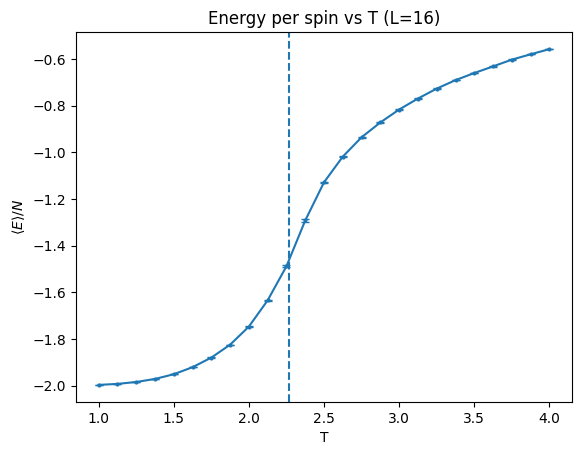

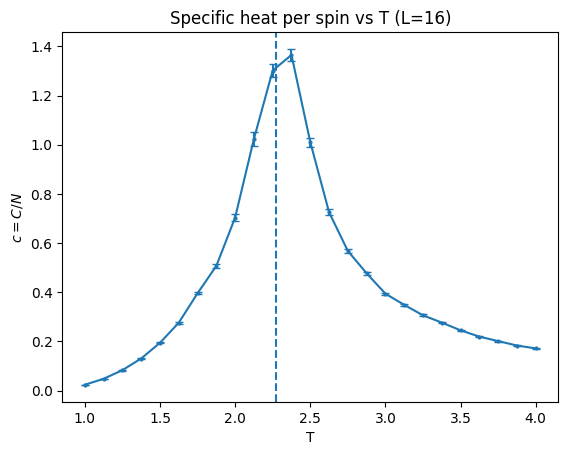

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ---------------- FAST vectorized 2D Ising Metropolis (checkerboard) ----------------
def init_spins(L, rng):
    return rng.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))

def total_energy(spins, J=1.0):
    # count each bond once: right + down
    E = (spins * np.roll(spins, -1, axis=0)).sum()
    E += (spins * np.roll(spins, -1, axis=1)).sum()
    return -J * E

def checkerboard_masks(L):
    ii, jj = np.indices((L, L))
    even = ((ii + jj) & 1) == 0
    odd = ~even
    return even, odd

def metropolis_sweep_checkerboard(spins, T, J, rng, even_mask, odd_mask):
    # Update even sites simultaneously, then odd sites.
    for mask in (even_mask, odd_mask):
        nn = (np.roll(spins, 1, 0) + np.roll(spins, -1, 0) +
              np.roll(spins, 1, 1) + np.roll(spins, -1, 1))
        dE = 2.0 * J * spins * nn  # energy change if flipped

        # acceptance: always accept if dE<=0; else accept with exp(-dE/T)
        accept = (dE <= 0.0)
        r = rng.random(spins.shape)
        accept |= (r < np.exp(-dE / T))

        flip = mask & accept
        spins[flip] *= -1

def run_chain_energies(L, T, J, warmup_sweeps, n_samples, sweeps_between_samples, seed=0):
    rng = np.random.default_rng(seed)
    spins = init_spins(L, rng)
    even, odd = checkerboard_masks(L)

    # warmup
    for _ in range(warmup_sweeps):
        metropolis_sweep_checkerboard(spins, T, J, rng, even, odd)

    energies = np.empty(n_samples, dtype=np.float64)
    for i in range(n_samples):
        for _ in range(sweeps_between_samples):
            metropolis_sweep_checkerboard(spins, T, J, rng, even, odd)
        energies[i] = total_energy(spins, J)
    return energies

# ---------------- fast 1σ uncertainties via blocking ----------------
def blocking_stats_E_c(energies, T, Nspins, block_size=200):
    M = len(energies)
    B = M // block_size
    if B < 3:
        raise ValueError("Need >=3 blocks: increase n_samples or reduce block_size.")

    e = energies[:B*block_size].reshape(B, block_size)

    # block estimates
    Eblk = e.mean(axis=1) / Nspins
    E2blk = (e**2).mean(axis=1)
    Emean_raw = e.mean(axis=1)  # per-block <E> (not per spin)
    cblk = (E2blk - Emean_raw**2) / (Nspins * T**2)

    # overall means
    E_mean = Eblk.mean()
    c_mean = cblk.mean()

    # 1σ uncertainty of the mean (standard error across blocks)
    E_err = Eblk.std(ddof=1) / np.sqrt(B)
    c_err = cblk.std(ddof=1) / np.sqrt(B)

    return E_mean, E_err, c_mean, c_err

# ---------------- Q2 run ----------------
L = 16               
J = 1.0
Nspins = L * L

Ts = np.linspace(1.0, 4.0, 25)
Tc = 2.269 * J

warmup_sweeps = 1000
n_samples = 20000
sweeps_between_samples = 1      
block_size = 200

Emean = np.empty_like(Ts)
Eerr  = np.empty_like(Ts)
cmean = np.empty_like(Ts)
cerr  = np.empty_like(Ts)

for i, T in enumerate(tqdm(Ts, desc="Q2 temperatures")):
    energies = run_chain_energies(
        L=L, T=T, J=J,
        warmup_sweeps=warmup_sweeps,
        n_samples=n_samples,
        sweeps_between_samples=sweeps_between_samples,
        seed=1234+i
    )
    Emean[i], Eerr[i], cmean[i], cerr[i] = blocking_stats_E_c(
        energies, T=T, Nspins=Nspins, block_size=block_size
    )

plt.figure()
plt.errorbar(Ts, Emean, yerr=Eerr, fmt="o-", ms=2, capsize=3)
plt.axvline(Tc, linestyle="--")
plt.xlabel("T")
plt.ylabel(r"$\langle E\rangle/N$")
plt.title(f"Energy per spin vs T (L={L})")
plt.show()

plt.figure()
plt.errorbar(Ts, cmean, yerr=cerr, fmt="o-", ms=2, capsize=3)
plt.axvline(Tc, linestyle="--")
plt.xlabel("T")
plt.ylabel(r"$c=C/N$")
plt.title(f"Specific heat per spin vs T (L={L})")
plt.show()

The plots are similar to the plots shown in the question, they share the same overall pattern. By looking at the error bars, we can see that they increase as you get closer to the critical temperature. This makes sense because near the critical temperature, the system develops more fluctuations. This increases the uncertainty in both $\langle E \rangle$ and $\langle C \rangle$.